In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/Applications/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [163]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [164]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   Дата          301355 non-null  str  
 1   Склад         301355 non-null  int64
 2   Контрагент    301355 non-null  str  
 3   Номенклатура  301355 non-null  str  
 4   Количество    301355 non-null  int64
dtypes: int64(2), str(3)
memory usage: 20.0 MB
None


Сразу переведем столбец "Дата" в правильный формат

In [165]:
df['Дата'] = pd.to_datetime(df['Дата'])
print(df.head())

        Дата  Склад Контрагент Номенклатура  Количество
0 2018-01-04      1  address_0    product_0           4
1 2018-01-04      1  address_0    product_1           4
2 2018-01-04      1  address_0    product_2           5
3 2018-01-04      1  address_0    product_3          10
4 2018-01-04      1  address_0    product_4           2


Сгруппируйте данные по дате, посчитайте количество продаж

In [166]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [167]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

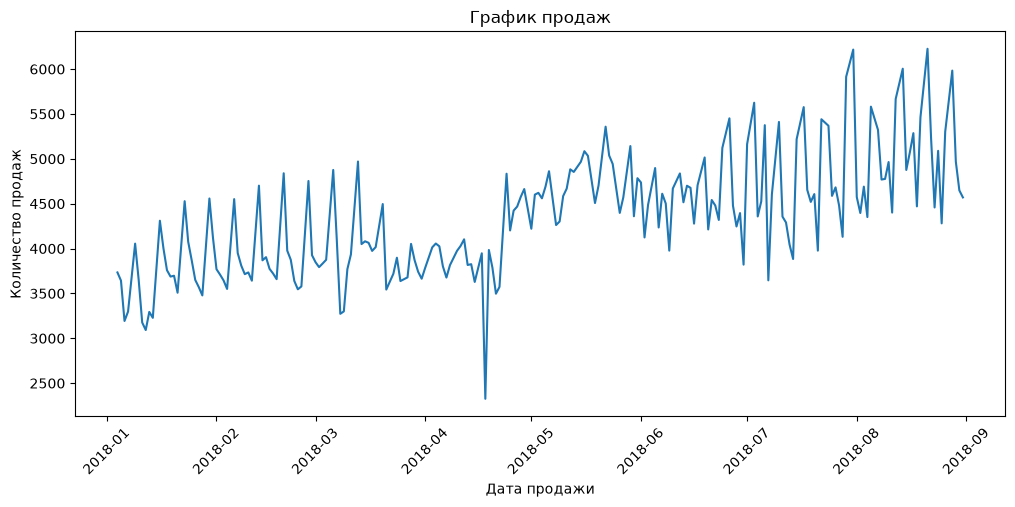

In [168]:
plt.figure(figsize=(12, 5))

plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.xlabel('Дата продажи')
plt.ylabel('Количество продаж')
plt.title('График продаж')

plt.xticks(rotation=45)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

На графике видно, что количество продаж достаточно нестабильно: оно значительно колеблется от дня к дню. В середине апреля наблюдается резкое падение продаж, примерно до 2,000 единиц, после чего показатель быстро возвращается к привычному уровню.

Начиная с мая наблюдается общая тенденция к росту количества продаж. Если в начале года продажи в основном находились примерно в диапазоне 3,000–4,500 единиц, то к августу они уже регулярно достигают 5,000–6,000 единиц. Таким образом, несмотря на сильные ежедневные колебания, в долгосрочной перспективе продажи имеют тенденцию к росту.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [169]:
Q1 = np.percentile(df['Количество'], 25)
Q3 = np.percentile(df['Количество'], 75)

outlier_border = Q3 + 1.5 * (Q3 - Q1)

print(f"Граница выброса: {outlier_border}")

outlier = df[df['Количество'] > outlier_border]['Количество'].max()

print(print(f"Максимальный выброс: {outlier}"))

Граница выброса: 8.5
Максимальный выброс: 200
None


In [170]:
Q1 = np.percentile(df['Количество'], 25)
Q2 = np.median(df['Количество'])
Q3 = np.percentile(df['Количество'], 75)

max_outlier = Q3 + 1.5 * (Q3 - Q1)

print(f"Граница выброса: {max_outlier}")

outlier = df[df['Количество'] > max_outlier].loc[
    df[df['Количество'] > max_outlier]['Количество'].idxmax()
]

print(outliers['Количество'].max())

Граница выброса: 8.5
200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [171]:
df['Дата'] = pd.to_datetime(df['Дата'])

top_product = (
    df[
        (df['Дата'].dt.month.isin([6, 7, 8])) &
        (df['Дата'].dt.dayofweek == 2) &
        (df['Склад'] == 3)
    ]
    .groupby('Номенклатура')['Количество']
    .sum()
    .idxmax()
)

print(f"Топовый товар: {top_product}")

Топовый товар: product_1


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [172]:
weather = pd.read_csv(
    'weather2.csv.gz',
    encoding='latin1',
    sep=';',
    skiprows=6
)

weather.head()

,ÐÐµÑÑÐ½Ð¾Ðµ Ð²ÑÐµÐ¼Ñ Ð² ÐÑÑÐ°Ð½Ðµ,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
01.09.2018 23:00,5.5,737.1,769.1,0.1,84.0,"ÐÐµÑÐµÑ, Ð´ÑÑÑÐ¸Ð¹ Ñ ÑÐµÐ²ÐµÑÐ¾-ÑÐµÐ...",2,NaN,NaN,100%.,...,NaN,NaN,2.9,Ð¡Ð»ÐµÐ´Ñ Ð¾ÑÐ°Ð´ÐºÐ¾Ð²,12.0,NaN,NaN,NaN,NaN,NaN
01.09.2018 20:00,6.1,737.0,769.0,1.0,78.0,"ÐÐµÑÐµÑ, Ð´ÑÑÑÐ¸Ð¹ Ñ ÑÐµÐ²ÐµÑÐ°",2,NaN,NaN,"90 Ð¸Ð»Ð¸ Ð±Ð¾Ð»ÐµÐµ, Ð½Ð¾ Ð½Ðµ 100%",...,"ÐÐµÑÐ¸ÑÑÑÑ , Ð¿ÐµÑÐ¸ÑÑÐ¾-ÐºÑÑÐµÐ²ÑÑ...",NaN,2.5,Ð¡Ð»ÐµÐ´Ñ Ð¾ÑÐ°Ð´ÐºÐ¾Ð²,12.0,NaN,NaN,NaN,NaN,NaN
01.09.2018 17:00,7.5,736.0,767.7,0.2,78.0,"ÐÐµÑÐµÑ, Ð´ÑÑÑÐ¸Ð¹ Ñ ÑÐµÐ²ÐµÑÐ¾-Ð²Ð¾Ñ...",1,NaN,NaN,"90 Ð¸Ð»Ð¸ Ð±Ð¾Ð»ÐµÐµ, Ð½Ð¾ Ð½Ðµ 100%",...,"ÐÐµÑÐ¸ÑÑÑÑ , Ð¿ÐµÑÐ¸ÑÑÐ¾-ÐºÑÑÐµÐ²ÑÑ...",10.0,3.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
01.09.2018 14:00,9.1,735.8,767.4,-0.5,55.0,"ÐÐµÑÐµÑ, Ð´ÑÑÑÐ¸Ð¹ Ñ ÑÐµÐ²ÐµÑÐ¾-ÑÐµÐ...",3,NaN,NaN,"90 Ð¸Ð»Ð¸ Ð±Ð¾Ð»ÐµÐµ, Ð½Ð¾ Ð½Ðµ 100%",...,"ÐÐµÑÐ¸ÑÑÑÑ , Ð¿ÐµÑÐ¸ÑÑÐ¾-ÐºÑÑÐµÐ²ÑÑ...",10.0,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
01.09.2018 11:00,7.7,736.3,768.1,-0.2,61.0,"ÐÐµÑÐµÑ, Ð´ÑÑÑÐ¸Ð¹ Ñ ÑÐµÐ²ÐµÑÐ¾-ÑÐµÐ...",3,NaN,NaN,100%.,...,NaN,10.0,0.5,Ð¡Ð»ÐµÐ´Ñ Ð¾ÑÐ°Ð´ÐºÐ¾Ð²,12.0,NaN,NaN,NaN,NaN,NaN


In [173]:
weather.index = pd.to_datetime(weather.index, dayfirst=True)

weather_daily = (
    weather.groupby(weather.index.normalize())[weather.columns[0]]
    .mean()
    .reset_index()
)

weather_daily.columns = ['Дата', 'Температура']

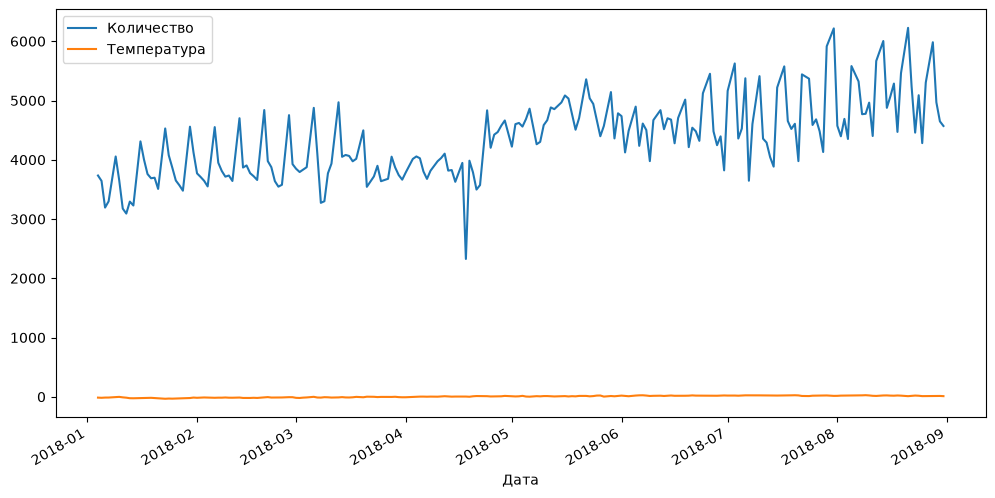

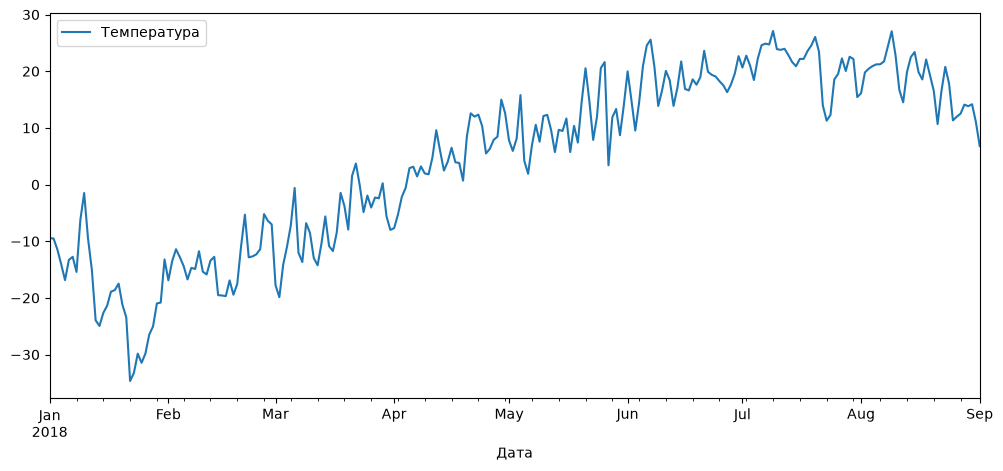

In [174]:
grouped_df = grouped_df.merge(weather_daily, on='Дата', how='left')

grouped_df.plot(
    x='Дата',
    y=['Количество', 'Температура'],
    figsize=(12, 6)
)

plt.show()

weather_daily.plot(
    x='Дата',
    y='Температура',
    figsize=(12, 5)
)

plt.show()